In [ ]:
#| default_exp laggedCcRec_ex

In [ ]:
#| hide

import plotly.io as pio

In [ ]:
#| hide
pio.renderers.default = "png"

# Analyze Lagged Cross Correlations of `Embedding`s of Wavelet-based Subbands

We use both color maps and time‑series plots for visual analysis. The lagged cross‑correlation map represents correlation as a function of both time and lag; fixing the lag collapses this 2‑D surface into a 1‑D series that shows how the correlation at that specific lag evolves over time. A lagged cross‑correlation time series at a fixed lag is therefore just the vertical slice of the full map taken at that lag.

## Lagged Cross Correlation Color Map

We demonstrate the usage of the `lagged_correlations` method of the `EmbeddingCollection` class.
It can be used in three ways: 

1. auto-correlations of a single feature of a subject 

2. between two features of a subject or 

3. between two subjects on the same feature.

### Auto-Correlations

In [ ]:
#| eval: false
from nbdev_fhemb.decomposeEmb_ex import wavelet_factory

In [ ]:
#| eval: false
from nbdev_fhemb.embedding_ex import dg0, pca

 [DEBUG] piece.project: Calling BaseDatasource.project with subjs=[66], features=['p50'], heatmap=None, fvector=None, fbands=[1, 2], pcfactory=None, wdfactory=<fhemb.utils.factories.ConcreteEmbFactory object>
 [DEBUG] piece._choose_embedding: Classified features: {'percentiles': ['p50'], 'bins': [], 'pcomponents': [], 'stat_features': []}
 [DEBUG] piece._choose_embedding: classified percentiles: ['p50']
 [DEBUG] piece.project: Chosen embeddings: [('percentiles_ts', {'embedding': <fhemb.embedding.Embedding object>, 'features': ['p50']})]
 [DEBUG] embedding.project: Calling project for subjects=[66] and features=['p50'], heatmap=None, fvector=None, fbands=[1, 2], factory=<fhemb.utils.factories.ConcreteEmbFactory object>
 [DEBUG] mixins.wrapper: Calling _create_wdecomposition_impl with stacklevel=2
 [DEBUG] mixins.wrapper: Processing features ['p50'], heatmap None, fvector None, args=(), and kwargs={'factory': <fhemb.utils.factories.ConcreteEmbFactory object>}
 [DEBUG] mixins.wrapper: Per

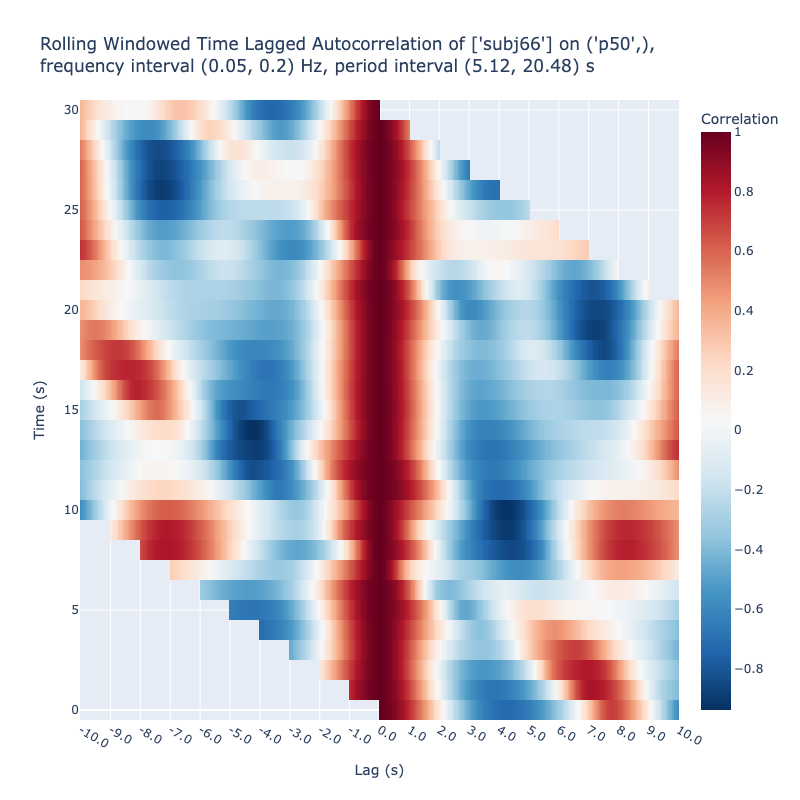

In [ ]:
#| eval: false

dg0.face_t.project(
    subjs=[66],                 # Subject of interest   
    features=['p50'],           # Features to be cross-correlated
    wdfactory=wavelet_factory,  # Specify the wavelet factory for decomposition
    fbands=[1,2],               # Frequency bands to include in the reconstruction 
).plot_lagged_correlations(
    twin=250,                   # Time window in frames
    step=25,                    # Step size in frames
    max_lag=250,                # Maximum lag in frames
)

### Cross-Correlations between two features

 [DEBUG] piece.project: Calling BaseDatasource.project with subjs=[66], features=['p45', 'median'], heatmap=None, fvector=None, fbands=[1, 2], pcfactory=None, wdfactory=<fhemb.utils.factories.ConcreteEmbFactory object>
 [DEBUG] piece._choose_embedding: Classified features: {'percentiles': ['p45'], 'bins': [], 'pcomponents': [], 'stat_features': ['median']}
 [DEBUG] piece._choose_embedding: classified percentiles: ['p45']
 [DEBUG] piece._choose_embedding: classified stat_features: ['median']
 [DEBUG] piece.project: Chosen embeddings: [('percentiles_ts', {'embedding': <fhemb.embedding.Embedding object>, 'features': ['p45']}), ('features_ts', {'embedding': <fhemb.embedding.Embedding object>, 'features': ['median']})]
 [DEBUG] embedding.project: Calling project for subjects=[66] and features=['p45'], heatmap=None, fvector=None, fbands=[1, 2], factory=<fhemb.utils.factories.ConcreteEmbFactory object>
 [DEBUG] mixins.wrapper: Calling _create_wdecomposition_impl with stacklevel=2
 [DEBUG] mix

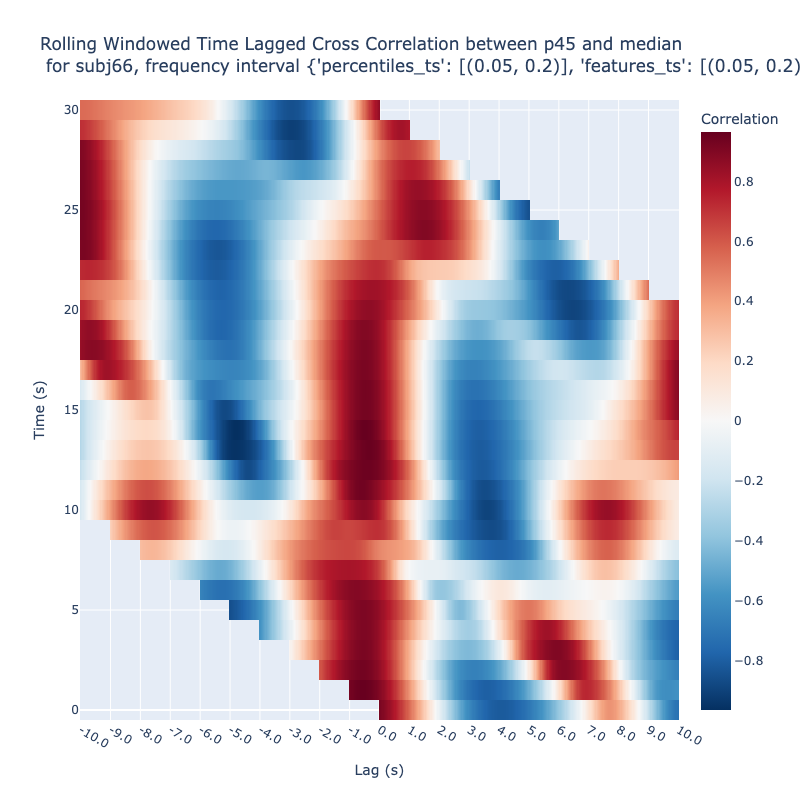

In [ ]:
#| eval: false

dg0.face_t.project(
    subjs=[66],                    # Subject of interest   
    features=['p45', 'median'],    # Features to be cross-correlated
    wdfactory=wavelet_factory,     # Specify the wavelet factory for decomposition
    fbands=[1,2],                  # Frequency bands to include in the reconstruction 
).plot_lagged_correlations(
    twin=250,                      # Time window in frames
    step=25,                       # Step size in frames
    max_lag=250,                   # Maximum lag in frames
)

::: {.callout-note}
Note that cross-correlation between median and 50-percentile would be effectively autocorrelation. It is expected that the cross-correlation between the median and 45-percentile have a similar pattern.  
:::

### Cross-Correlations between two subjects

 [DEBUG] piece.project: Calling BaseDatasource.project with subjs=[40, 65], features=['pc0'], heatmap=None, fvector=None, fbands=[1, 2], pcfactory=<fhemb.utils.factories.ConcretePcaFactory object>, wdfactory=<fhemb.utils.factories.ConcreteEmbFactory object>
 [DEBUG] piece._choose_embedding: Classified features: {'percentiles': [], 'bins': [], 'pcomponents': ['pc0'], 'stat_features': []}
 [DEBUG] piece._choose_embedding: classified pcomponents: ['pc0']
 [DEBUG] piece.create_pca_embedding: Calling create_pca_embedding
 [DEBUG] tutils.create: Creating create_pca_embedding with args: StandardScaler(copy=True,with_mean=True,with_std=False) | KernelPCA(alpha=1.0,coef0=1,copy_X=True,degree=3,eigen_solver='auto',fit_inverse_transform=True,gamma=0.07,iterated_power='auto',kernel='sigmoid',kernel_params=None,max_iter=None,n_components=5,n_jobs=None,random_state=None,remove_zero_eig=False,tol=0) and kwargs: dict_keys(['factory', 'datasource', 'subjects', 'time_interval', 'temperature_threshold'])

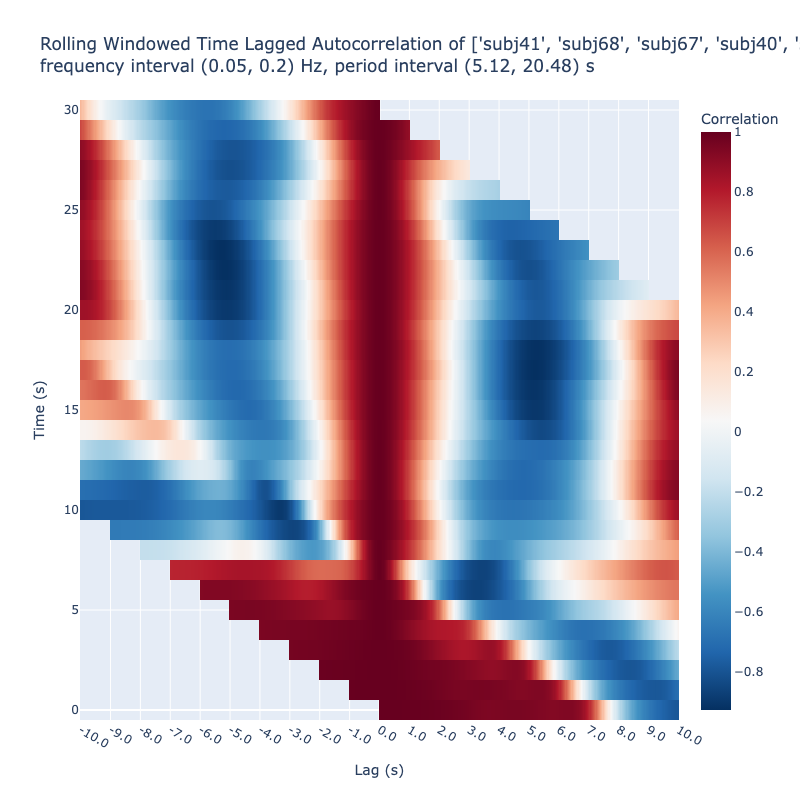

In [ ]:
#| eval: false

dg0.face_t.project(
    subjs=[40,65],                # Specify subjects to be cross-correlated
    features=['pc0'],             # on a single feature - principle component 0
    pcfactory=pca,                # Specify the PCA  
    wdfactory=wavelet_factory,    # Specify the wavelet factory for decomposition
    fbands=[1,2],                 # Frequency bands to include in the reconstruction 
).plot_lagged_correlations(
    twin=250,                     # Time window in frames 
    step=25,                      # Step size in frames
    max_lag=250,                  # Maximum lag in frames
)

## Lagged Cross Correlation Time Series

 [DEBUG] piece.project: Calling BaseDatasource.project with subjs=all, features=['pc0', 'p10'], heatmap=None, fvector=None, fbands=[1, 2], pcfactory=<fhemb.utils.factories.ConcretePcaFactory object>, wdfactory=<fhemb.utils.factories.ConcreteEmbFactory object>
 [DEBUG] piece._choose_embedding: Classified features: {'percentiles': ['p10'], 'bins': [], 'pcomponents': ['pc0'], 'stat_features': []}
 [DEBUG] piece._choose_embedding: classified percentiles: ['p10']
 [DEBUG] piece._choose_embedding: classified pcomponents: ['pc0']
 [DEBUG] piece.create_pca_embedding: Calling create_pca_embedding
 [DEBUG] tutils.create: Creating create_pca_embedding with args: StandardScaler(copy=True,with_mean=True,with_std=False) | KernelPCA(alpha=1.0,coef0=1,copy_X=True,degree=3,eigen_solver='auto',fit_inverse_transform=True,gamma=0.07,iterated_power='auto',kernel='sigmoid',kernel_params=None,max_iter=None,n_components=5,n_jobs=None,random_state=None,remove_zero_eig=False,tol=0) and kwargs: dict_keys(['facto

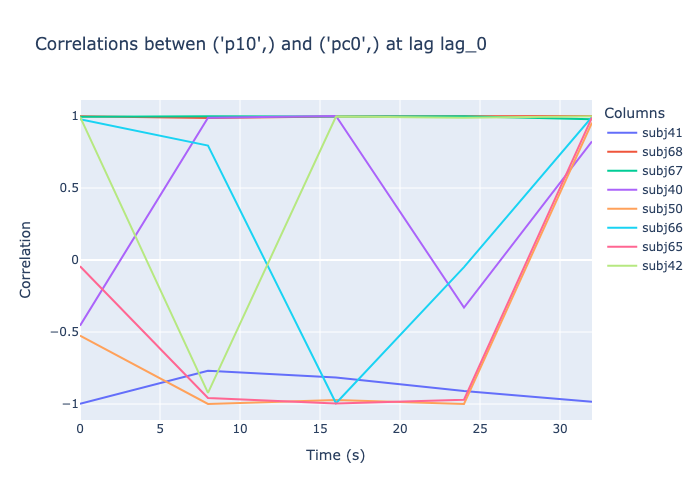

In [ ]:
#| eval: false

dg0.face_t.project(
    features=['pc0', 'p10'],      # on a single feature - principle component 0
    pcfactory=pca,                # Specify the PCA  
    wdfactory=wavelet_factory,    # Specify the wavelet factory for decomposition
    fbands=[1,2],                 # Frequency bands to include in the reconstruction 
).lagged_correlation_graph(
    twin=50,                      # Time window in frames
    step=200,                     # Step size in frames
    max_lag=0,                    # Maximum lag in frames
)

## Numeric Values

In [ ]:
#| eval: false

dg0.face_t.project(
    subjs=[40,65],                # Specify subjects to be cross-correlated
    features=['pc0'],             # on a single feature - principle component 0
    pcfactory=pca,                # Specify the PCA  
    wdfactory=wavelet_factory,    # Specify the wavelet factory for decomposition
    fbands=[1,2],                 # Frequency bands to include in the reconstruction 
).lagged_correlations_df(
    twin=50,                      # Time window in frames
    step=200,                     # Step size in frames
    max_lag=2,                    # Maximum lag in frames
)

 [DEBUG] piece.project: Calling BaseDatasource.project with subjs=[40, 65], features=['pc0'], heatmap=None, fvector=None, fbands=[1, 2], pcfactory=<fhemb.utils.factories.ConcretePcaFactory object>, wdfactory=<fhemb.utils.factories.ConcreteEmbFactory object>
 [DEBUG] piece._choose_embedding: Classified features: {'percentiles': [], 'bins': [], 'pcomponents': ['pc0'], 'stat_features': []}
 [DEBUG] piece._choose_embedding: classified pcomponents: ['pc0']
 [DEBUG] piece.create_pca_embedding: Calling create_pca_embedding
 [DEBUG] tutils.create: Creating create_pca_embedding with args: StandardScaler(copy=True,with_mean=True,with_std=False) | KernelPCA(alpha=1.0,coef0=1,copy_X=True,degree=3,eigen_solver='auto',fit_inverse_transform=True,gamma=0.07,iterated_power='auto',kernel='sigmoid',kernel_params=None,max_iter=None,n_components=5,n_jobs=None,random_state=None,remove_zero_eig=False,tol=0) and kwargs: dict_keys(['factory', 'datasource', 'subjects', 'time_interval', 'temperature_threshold'])

{'df': {'subj40':         lag_-2    lag_-1  lag_0     lag_1     lag_2
  0.0        NaN       NaN    1.0  0.989073  0.954361
  8.0   0.999988  0.999997    1.0  0.999998  0.999991
  16.0  0.999897  0.999975    1.0  0.999979  0.999927
  24.0  0.997815  0.999477    1.0  0.999525  0.998202
  32.0  0.948537  0.986760    1.0  0.987126  0.951693,
  'subj41':         lag_-2    lag_-1  lag_0     lag_1     lag_2
  0.0        NaN       NaN    1.0  0.991794  0.963841
  8.0   0.979360  0.995503    1.0  0.996664  0.988506
  16.0  0.999940  0.999986    1.0  0.999988  0.999955
  24.0  0.999822  0.999942    1.0  0.999921  0.999651
  32.0  0.999111  0.999767    1.0  0.999749  0.998964,
  'subj42':         lag_-2    lag_-1  lag_0     lag_1     lag_2
  0.0        NaN       NaN    1.0  0.999077  0.996650
  8.0   0.999496  0.999867    1.0  0.999858  0.999424
  16.0  0.999602  0.999907    1.0  0.999923  0.999735
  24.0  0.999587  0.999891    1.0  0.999886  0.999554
  32.0  0.999935  0.999983    1.0  0.999982 

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()